### Core Selection

To select the core you wish to do analysis on enter the core below in the following format "[Core Letter-CoreNumbers]" Ex "N-12"

In [20]:
core_selection='O-7' #N-12, O-6, etc

### Inline plot option
This block makes the plots in some of the cells appear in the cell rather than a seperate plot in a new tab. Would reommend enabling this to make this run faters. 

In [3]:
# At the very top of your notebook- Sets graphs to output in the notebook. 
%matplotlib inline

### General Setup

In [1]:
# requires cell_annotation environment
import sys
import os
import io
import json
import importlib
import numpy as np
import collections
import scipy
import sklearn
import pysankey
#from pySankey.sankey import sankey # move to plot_utils in future

import seaborn as sns
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.gridspec import GridSpec

from sklearn.preprocessing import StandardScaler

#Fix version of the path call which does not shorten the working directory by two each time it is run. 
if 'ORIGINAL_DIR' not in globals():
    ORIGINAL_DIR = os.getcwd()

root_dir = os.path.abspath(os.path.join(ORIGINAL_DIR, '..', '..'))
os.chdir(root_dir)

sys.path.append(os.path.join(root_dir, 'src', 'functions'))

import annotation_utils
import anno_class
import core_class_test
import classifier_class
import plot_utils

display(root_dir)

'C:\\Users\\evanj\\Documents\\2025-Dinh-Lab-Research-Project\\Fluoro-forest-main\\Fluoro-forest-main'

### Core Load 

This cell loads in the selected core. Makes the following filepath assumptions:

In [21]:
display(root_dir)

markers = pd.read_csv(os.path.join(root_dir, 'example_data', 'anal_cancer', 'raw', 'channelnames.txt'), header = None)[0]
marker_info = {marker:[i, 0, 255] for i, marker in enumerate(markers)}

# Set up as list if wanting to store more than one TMA core at a time
summaries_dir = os.path.join(root_dir, 'example_data', 'anal_cancer', 'summaries')

expression_dir= os.path.join(root_dir, 'example_data', 'anal_cancer', f"{core_selection}",'expression')
image_dir= os.path.join(root_dir, 'example_data', 'anal_cancer', f"{core_selection}",'image')
segmentation_dir= os.path.join(root_dir, 'example_data', 'anal_cancer', f"{core_selection}",'segmentation')

display(expression_dir)
display(image_dir)
display(segmentation_dir)

core_dict = collections.defaultdict()

# set up in case more than one
if core_selection in ["N-12","C-7"]:
    for core in [core_selection]:
        display(core)
        core_coords = pd.read_csv(os.path.join(summaries_dir, f'{core}_coords.csv'))
        core_coords.set_index('Object.ID', inplace = True)
        
        core_exprs = pd.read_csv(os.path.join(summaries_dir, f'{core}_expression.csv'))
        core_exprs.set_index('Object.ID', inplace = True)
        core_exprs.loc[core_coords.index,'X_coord'] = core_coords['Centroid.X.um']
        core_exprs.loc[core_coords.index,'Y_coord'] = -1*core_coords['Centroid.Y.um'] # inverted y, for how images are displayed
        core_image = annotation_utils.read_ome_tiff(os.path.join(root_dir, 'example_data', 'anal_cancer', 'processed', f'{core}.ome.tif'))
    
        # first segmentation is bounding box of core, not needed - Qupath specific workflow
        core_segments = annotation_utils.read_geom_json(os.path.join(root_dir, 'example_data', 'anal_cancer','segmentations', f'{core}.geojson'))[1:]
        core_segs_restr = {}
        
        for feature in core_segments:
            core_segs_restr.update(annotation_utils.transform_geometry(feature)) # converts geom_json object into dictionary of coordinates
    
        core_dict[core] = core_class_test.core_data(expression_data = core_exprs, 
                                               image = core_image, # tif
                                               segments = core_segs_restr, # restructured segmentations
                                               core = core, # name
                                               marker_info = marker_info) # marker channels / slice
else:
    for core in [core_selection]:
        display(core)
        core_coords = pd.read_csv(os.path.join(expression_dir, f'{core}_meta.csv'))
        core_coords.set_index('Object.ID', inplace = True)
        
        # Load CSV file
        csv_path = os.path.join(expression_dir, f'{core}_expression.csv')
        core_exprs = pd.read_csv(csv_path)
        
        # If the first column header is blank or missing, set it to 'Object.ID'
        if core_exprs.columns[0] in [None, '', 'Unnamed: 0']:
            core_exprs.rename(columns={core_exprs.columns[0]: 'Object.ID'}, inplace=True)
        
        # Now safely set it as the index
        core_exprs.set_index('Object.ID', inplace=True)
        core_exprs.loc[core_coords.index,'X_coord'] = core_coords['Centroid.X.um']
        core_exprs.loc[core_coords.index,'Y_coord'] = -1*core_coords['Centroid.Y.um'] # inverted y, for how images are displayed
        core_image = annotation_utils.read_ome_tiff(os.path.join(image_dir, f'{core}.ome.tif'))
    
        # first segmentation is bounding box of core, not needed - Qupath specific workflow
        core_segments = annotation_utils.read_geom_json(os.path.join(segmentation_dir, f'{core}.geojson'))[1:]
        core_segs_restr = {}
        
        for feature in core_segments:
            core_segs_restr.update(annotation_utils.transform_geometry(feature)) # converts geom_json object into dictionary of coordinates
    
        core_dict[core] = core_class_test.core_data(expression_data = core_exprs, 
                                               image = core_image, # tif
                                               segments = core_segs_restr, # restructured segmentations
                                               core = core, # name
                                               marker_info = marker_info) # marker channels / slice
    


# visualization of what the expression data shows, each row is a cell ID, columns represent normalized expression data
core_selected = core_dict[core_selection]

'C:\\Users\\evanj\\Documents\\2025-Dinh-Lab-Research-Project\\Fluoro-forest-main\\Fluoro-forest-main'

'C:\\Users\\evanj\\Documents\\2025-Dinh-Lab-Research-Project\\Fluoro-forest-main\\Fluoro-forest-main\\example_data\\anal_cancer\\O-7\\expression'

'C:\\Users\\evanj\\Documents\\2025-Dinh-Lab-Research-Project\\Fluoro-forest-main\\Fluoro-forest-main\\example_data\\anal_cancer\\O-7\\image'

'C:\\Users\\evanj\\Documents\\2025-Dinh-Lab-Research-Project\\Fluoro-forest-main\\Fluoro-forest-main\\example_data\\anal_cancer\\O-7\\segmentation'

'O-7'

### General Core Runs

Making the following assumptions
1. Visualization steps can be skipped

In [22]:
# features of interest (all markers) averaged across entire cell segmentation (Cell_Mean) from Qupath workflow
foi = list(core_exprs.columns[~core_exprs.columns.str.contains('DAPI|orig|Cent|coord|Membr|Nucl|Cyto')])
foi

['Ki67_Cell_Mean',
 'CD31_Cell_Mean',
 'FOXP3_Cell_Mean',
 'CD56_Cell_Mean',
 'CD34_Cell_Mean',
 'CD4_Cell_Mean',
 'CD20_Cell_Mean',
 'CD45_Cell_Mean',
 'CD163_Cell_Mean',
 'HLA.A_Cell_Mean',
 'LAG3_Cell_Mean',
 'CD8_Cell_Mean',
 'SMA_Cell_Mean',
 'PDL1_Cell_Mean',
 'CD21_Cell_Mean',
 'IDO1_Cell_Mean',
 'b.Catenin1_Cell_Mean',
 'CD14_Cell_Mean',
 'PD.1_Cell_Mean',
 'CD44_Cell_Mean',
 'CD3e_Cell_Mean',
 'CD45RO_Cell_Mean',
 'CD68_Cell_Mean',
 'Granzyme.B_Cell_Mean',
 'HLA.DR_Cell_Mean',
 'ICOS_Cell_Mean',
 'HIF1A_Cell_Mean',
 'CK17_Cell_Mean']

#### Lieden Clustering Inital

Running PCA...


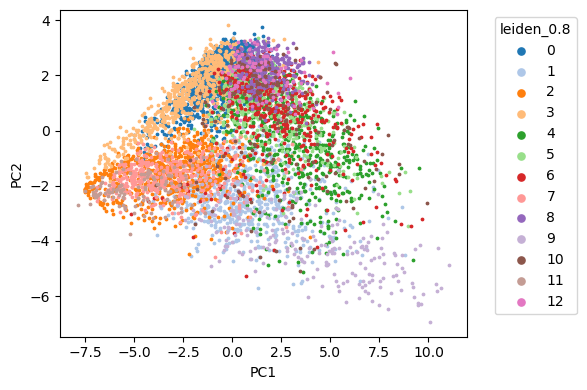

In [23]:
for key, core in core_dict.items():
    core.select_features(feats = foi)
    core.run_pca()
    core.run_leiden(resolution = 0.5, random_state = 5) 
    core.run_leiden(resolution = 0.8, random_state = 5)
    core.approximate_bounds()

# defining lineage level markers to guide subsclustering steps
marker_dict = {'immune': 'CD45_Cell_Mean', 
               'cd31_stroma':'CD31_Cell_Mean', 
               'sma_stroma':'SMA_Cell_Mean', 
               'epithelia':'Pan.Cytokeratin_Cell_Mean'}

core_selected.lineage_split(marker_dictionary = marker_dict, random_state = 5)

# leiden clustering alone overclusters epithelial cells
plot_utils.cell_plot(core = core_selected, 
                     figsize = (6,4),
                     plot_type = 'PC',
                     col = 'leiden_0.8', 
                     coloring_type = 'categorical', 
                     size = 3,
                     alpha = 1,
                     palette = 'tab20')

#### K means clustering

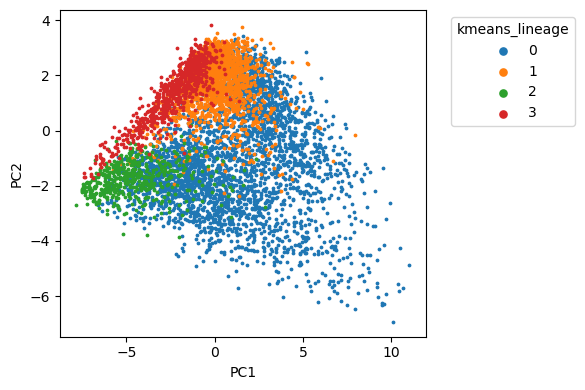

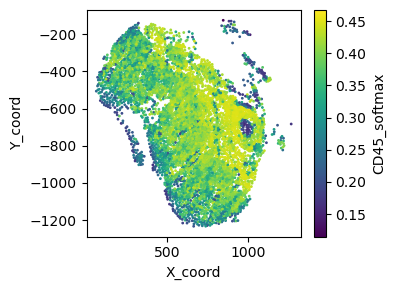

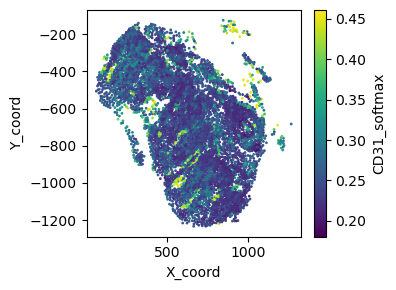

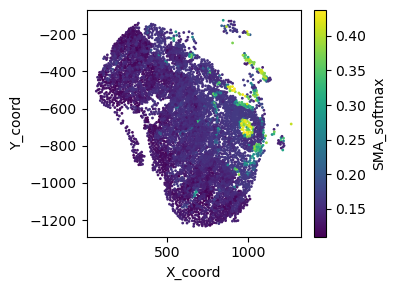

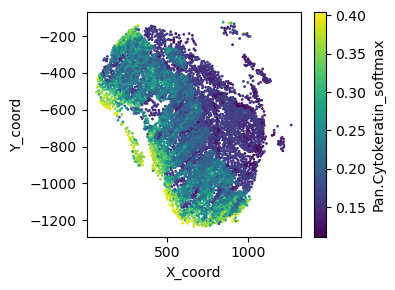

In [24]:
# visualizing broad lineage level clustering
plot_utils.cell_plot(core = core_selected, 
                     figsize = (6,4),
                     plot_type = 'PC',
                     col = 'kmeans_lineage', 
                     coloring_type = 'categorical', 
                     size = 3,
                     alpha = 1,
                     palette = 'tab10') #

# plotting softmeax expression on the segmentations itself supports non-overlapping lineages
for marker in list(marker_dict.values()):
    clr = marker.replace('_Cell_Mean', '_softmax')
    plot_utils.cell_plot(core_selected, 
                         plot_type = 'cell', 
                         coloring_type = 'continuous', 
                         col = clr, 
                         figsize = (4,3), 
                         size = 1)

resolution_dict = {'0': 0.3, # epithelia
                   '1': 0.5, # immune
                   '2': 0.5, # immune mixed
                   '3': 0.2} # stroma 2

core_selected.run_stratified_clustering(resolution_dict = resolution_dict, 
                                  cluster_method = 'leiden')

### Annotations

In [25]:
core_selected.cell_sampler(cluster_col = 'stratified_cluster', 
                     max_sample = 75, 
                     keep_oob = False, 
                     tolerance = 1, 
                     use_fps = True, 
                     random_state = 16)

len(core_selected.sampled_cells)

1322

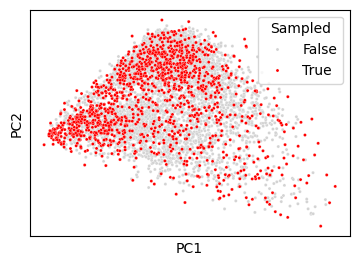

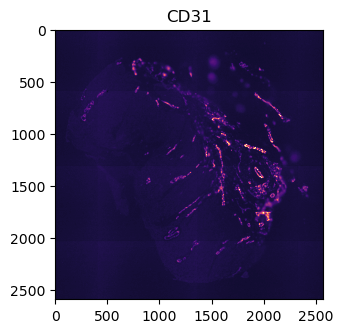

In [26]:
# example of what cells were sampled from the cell_sampler function visualized on the first 2 principal componenets
# used to visually support cell sampling comes from a diverse collection of cells

temp_df = core_selected.plot_df.copy()
temp_df.loc[:,'Sampled'] = False
temp_df.loc[core_selected.sampled_cells,'Sampled'] = True

temp_df = temp_df.sort_values('Sampled')

plt.figure(figsize = (4,3))
sns.scatterplot(data = temp_df,  
                x = 'PC1', 
                y = 'PC2', 
                s = 5,
                hue = 'Sampled', 
                palette = ['lightgray', 'red'])

plt.tight_layout()
plt.xticks([])
plt.yticks([])
plt.show()

# these were fine tuned to improve visability of cell types during annotation.
# currently in the core class, a dictionary of each marker exists, with a list where:
# 0th index is what slice of the image contains the specified marker
# 1st index is lower bound of what to visualize (in image)
# 2nd index is upper bound of what to visualize (in image)

core_selected.marker_info['DAPI'] = [0,5,250]
core_selected.marker_info['PanCK'] = [16,0,30]
core_selected.marker_info['CD31'] = [2,0,20]
core_selected.marker_info['SMA'] = [13,0,30]
core_selected.marker_info['CD45'] = [8,5,100]
core_selected.marker_info['CD3e'] = [22,0,20]
core_selected.marker_info['CD4'] = [6,0,20]
core_selected.marker_info['CD8'] = [12,0,30]
core_selected.marker_info['FOXP3'] = [3,5,20]
core_selected.marker_info['CD14'] = [19,0,20]
core_selected.marker_info['CD68'] = [24,3,20]
core_selected.marker_info['CD163'] = [9,0,15]
core_selected.marker_info['HLA-DR'] = [26,0,15]
core_selected.marker_info['CD56'] = [4,2,15]
core_selected.marker_info['CD20'] = [7,2,20]
core_selected.marker_info['CK17'] = [29,0,15]

core_selected.plot_marker(marker = 'CD31') # adjust manually above and determine appropriate threshold by viewing on whole core

In [27]:
# cell annotations
core_selected.annotate(show_markers = ['DAPI', 'PanCK', 'CD31', 'SMA',
                                 'CD45', 'CD3e', 'CD4', 'CD8', 
                                 'FOXP3', 'CD14', 'CD68', 'CD163',
                                 'HLA-DR', 'CD56', 'CD20', 'CK17'], 
                   cell_types = ['Epi', 'Endothelia', 'Stroma', 
                                 'CD4_T', 'CD8_T','Treg', 'NK', 'Bcell',
                                 'Myeloid','Other_immune', 'Unknown'])

### Saving Manual Annotations

In [ ]:
# annotations can be saved part way through after quitting the application and saved out / read back in
annotations_dir = os.path.join(root_dir, 'example_data', 'anal_cancer', 'temp_annotations')

display(annotations_dir)
# saving out:
pd.DataFrame.from_dict(core_selected.annotations, orient = 'index').to_csv(os.path.join(annotations_dir, 'O6_annotations_Evan2.csv'))


In [ ]:
import pandas as pd
import os

# Read the annotations CSV
result = pd.read_csv(os.path.join(annotations_dir, 'O6_annotations_Evan2.csv'))

# Standardize column names
result.columns = ['Object.ID', 'Annotation']

# Print the count of each unique annotation value
print("Annotation counts:")
print(result['Annotation'].value_counts())

# Convert to dictionary {Object.ID: Annotation}
result_dict = result.set_index('Object.ID')['Annotation'].to_dict()

# Assign to your core object
core_selected.annotations = result_dict
